## **Medical Inventory Demand Prediction and Analysis System**

## Problem Statement

The objective of this project is to analyze medical inventory data to predict product sales using machine learning models and to identify product behavior patterns through clustering techniques. The goal is to improve inventory management by understanding demand and stock movement.

## Step 1: Import all Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

## Step 2: Data Cleaning and Preprocessing

Product Level Data - Preprocessing

In [ ]:
raw_df = pd.read_csv("Medical Stocks.csv")

print("RAW PRODUCT DATASET")
print(raw_df.shape)
print(raw_df.columns)
raw_df.head()

In [ ]:
# remove Age column
raw_df = raw_df.drop(columns=["Age"], errors="ignore")

# clean column names
raw_df.columns = raw_df.columns.str.strip()

# clean text columns
for col in raw_df.select_dtypes(include="object").columns:
    raw_df[col] = raw_df[col].astype(str).str.strip()

# columns used to detect useless rows
activity_cols = ["OStk", "PurTot", "TotQty", "SaleTot", "Qoh", "QohValue"]

# remove rows where all activity columns are 0
raw_df = raw_df.dropna(subset=activity_cols, how = 'all')

print("AFTER BASIC CLEANING")
print(raw_df.shape)
raw_df.head()

In [ ]:
raw_df.to_csv("Medical_Stocks_Cleaned_with_packing.csv", index=False)
print("Intermediate cleaned product dataset saved as Medical_Stocks_Cleaned.csv")

Intermediate cleaned product dataset saved as Medical_Stocks_Cleaned.csv


### Packing Standardization

The 'Packing' column contained inconsistent formats such as:
- 10S, 15ml, 30ML, 225ml.

Due to this inconsistency, a validated dataset was prepared where:
- Packing is split into numeric quantity  
- Type represents the unit/category  

This standardized dataset is used for final preprocessing.

In [ ]:
product_df = pd.read_csv("Medical_Stocks_Final.csv")

print(product_df.shape)
product_df.head()

In [ ]:
# clean column names
product_df.columns = product_df.columns.str.strip()

# clean text columns
for col in product_df.select_dtypes(include="object").columns:
    product_df[col] = product_df[col].astype(str).str.strip()

# standardize type column
product_df["type"] = product_df["type"].str.lower()

# rename typo
product_df = product_df.rename(columns={"Comapny": "Company"})

# convert numeric columns
num_cols = ["Packing", "OStk", "PurTot", "TotQty", "SaleTot", "Qoh", "QohValue"]

for col in num_cols:
    product_df[col] = pd.to_numeric(product_df[col], errors="coerce")


print(product_df.shape)
product_df.head()

### Saving Final Product Dataset

In [ ]:
product_df.to_csv("Product_Level_Data_Final.csv", index=False)

Company Level Data - Preprocessing

In [ ]:
company_df = pd.read_csv("Comapny level data.csv")

print(company_df.shape)
company_df.head()

In [ ]:
# clean column names
company_df.columns = company_df.columns.str.strip()

# clean text columns
for col in company_df.select_dtypes(include="object").columns:
    company_df[col] = company_df[col].astype(str).str.strip()

# rename typo
company_df = company_df.rename(columns={"Comapny": "Company"})

# replace 0 with NaN
company_df = company_df.replace(0, np.nan)

# remove rows with no values
target_cols = ['Opening Value', 'Sale Value', 'Purchase Value', 'Closing Value']
company_df = company_df.dropna(subset=target_cols, how = 'all')

# fill back with 0
company_df = company_df.fillna(0)

print(company_df.shape)
company_df.head()

### Saving Final Company Dataset

In [ ]:
company_df.to_csv("Company_level_data_Final.csv", index=False)

## Final Cleaned Datasets

In [ ]:
stock = pd.read_csv("Product_Level_Data_Final.csv")
company = pd.read_csv("Company_level_data_Final.csv")

print("Stock Dataset:", stock.shape)
print("Company Dataset:", company.shape)

print(stock.head())
company.head()

Stock Dataset: (2268, 10)
Company Dataset: (114, 5)
  Company               Name  Packing type  OStk  PurTot  TotQty  SaleTot  \
0   ABOTT  APETITE SYP 200ML    200.0   ml    13       0      13        2   
1   ABOTT  AZRO-100 ORAL SYP     30.0   ml    28       0      28        3   
2   ABOTT       AZRO-200 SYP     30.0   ml    21       0      21        2   
3   ABOTT      BREATH-DX SYP    100.0   ml     7       0       7        0   
4   ABOTT     BRUFEN 400 TAB     15.0    s    24       0      24        0   

   Qoh  QohValue  
0   11    754.15  
1   25   1370.70  
2   19   1098.92  
3    7    330.62  
4   24    439.84  


,Company,Opening Value,Sale Value,Purchase Value,Closing Value
0,ABOTT,0.0,21872.59,7006.08,23967.88
1,ABOTFOOD,0.0,0.00,0.00,427.03
2,ACILOPHARM,0.0,8370.00,12856.80,88095.55
3,AGILPHARM,0.0,0.00,0.00,1648.78
4,AJANT,0.0,2239.40,4078.40,9378.75


In [ ]:
stock['type'] = (
    stock['type']
    .astype(str)
    .str.lower()
    .str.strip()
)

stock['type'] = stock['type'].replace({
    # gram variations
    'g': 'gram',
    'gm': 'gram',
    'gms': 'gram',
    'gr': 'gram',
    'grm': 'gram',
    'vail': 'vial',
    't': 'tab',
    'tub': 'tab',
    's': 'sach',
    'm': 'ml',
    'md': 'ml'
})

stock = stock[stock['type'] != 'iu']

## Step 3: Exploratory Data Analysis & Visualization

In [ ]:
# Group the Product-Level Dataset by Company

df_grouped = stock.groupby("Company").agg({
    "OStk": "sum",
    "PurTot": "sum",
    "TotQty": "sum",
    "SaleTot": "sum",
    "Qoh": "sum",
    "QohValue": "sum"
}).reset_index()

print("Grouped company-level summary from product dataset:")
display(df_grouped.head())

Grouped company-level summary from product dataset:


,Company,OStk,PurTot,TotQty,SaleTot,Qoh,QohValue
0,ABOTT,518,128,646,254,392,23967.86
1,ABOTT FOOD,1,0,1,0,1,427.03
2,ACILOX PHARMA,747,145,892,180,712,88095.55
3,AGILE PHARMA,-69,0,-69,0,-69,1648.78
4,AJANTA,35,24,59,9,50,9378.76


In [ ]:
# Rename Aggregated Columns

df_grouped.rename(columns={
    "OStk": "Grouped_OStk",
    "PurTot": "Grouped_PurTot",
    "TotQty": "Grouped_TotQty",
    "SaleTot": "Grouped_SaleTot",
    "Qoh": "Grouped_Qoh",
    "QohValue": "Grouped_QohValue"
}, inplace=True)

display(df_grouped.head())

# Verify Grouped Data
duplicate_companies = df_grouped["Company"].duplicated().sum()
print("Number of duplicate companies in grouped dataset:", duplicate_companies)

,Company,Grouped_OStk,Grouped_PurTot,Grouped_TotQty,Grouped_SaleTot,Grouped_Qoh,Grouped_QohValue
0,ABOTT,518,128,646,254,392,23967.86
1,ABOTT FOOD,1,0,1,0,1,427.03
2,ACILOX PHARMA,747,145,892,180,712,88095.55
3,AGILE PHARMA,-69,0,-69,0,-69,1648.78
4,AJANTA,35,24,59,9,50,9378.76


Number of duplicate companies in grouped dataset: 0


In [ ]:
# Merge the Grouped Data with the Company-Level Dataset

company_grouped = company.merge(df_grouped,
    on="Company",
    how="left"
    )

display(company_grouped.head())

,Company,Opening Value,Sale Value,Purchase Value,Closing Value,Grouped_OStk,Grouped_PurTot,Grouped_TotQty,Grouped_SaleTot,Grouped_Qoh,Grouped_QohValue
0,ABOTT,0.0,21872.59,7006.08,23967.88,518.0,128.0,646.0,254.0,392.0,23967.86
1,ABOTFOOD,0.0,0.00,0.00,427.03,NaN,NaN,NaN,NaN,NaN,NaN
2,ACILOPHARM,0.0,8370.00,12856.80,88095.55,NaN,NaN,NaN,NaN,NaN,NaN
3,AGILPHARM,0.0,0.00,0.00,1648.78,NaN,NaN,NaN,NaN,NaN,NaN
4,AJANT,0.0,2239.40,4078.40,9378.75,NaN,NaN,NaN,NaN,NaN,NaN


### Datasets Validation

Product Level Stocks Dataset

In [ ]:
# Product Level Stocks Dataset

print("Final Product Level dataset shape:", stock.shape)
print("\nFinal dataset info:")
print(stock.info())
print(stock.describe())

# Drop Nan Values
stock = stock.dropna()

print("\nMissing values in final dataset:")
print(stock.isnull().sum())

Final Product Level dataset shape: (2267, 10)

Final dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 2267 entries, 0 to 2267
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Company   2267 non-null   object 
 1   Name      2267 non-null   object 
 2   Packing   2264 non-null   float64
 3   type      2267 non-null   object 
 4   OStk      2267 non-null   int64  
 5   PurTot    2267 non-null   int64  
 6   TotQty    2267 non-null   int64  
 7   SaleTot   2267 non-null   int64  
 8   Qoh       2267 non-null   int64  
 9   QohValue  2267 non-null   float64
dtypes: float64(2), int64(5), object(3)
memory usage: 194.8+ KB
None
           Packing         OStk       PurTot       TotQty      SaleTot  \
count  2264.000000  2267.000000  2267.000000  2267.000000  2267.000000   
mean     29.622792    18.170269     6.017203    24.187472     8.305249   
std      53.675783    48.022071    35.555312    67.495328    24.739800  

Final Company Level Dataset

In [ ]:
# Company Level Dataset after Joining

print("Final Company Level dataset shape:", company_grouped.shape)
print("\nFinal dataset info:")
print(company_grouped.info())
print(company_grouped.describe())

# Drop empty rows
company_grouped = company_grouped.dropna()

print("\nMissing values in final dataset:")
print(company_grouped.isnull().sum())

Final Company Level dataset shape: (114, 11)

Final dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           114 non-null    object 
 1   Opening Value     114 non-null    float64
 2   Sale Value        114 non-null    float64
 3   Purchase Value    114 non-null    float64
 4   Closing Value     114 non-null    float64
 5   Grouped_OStk      75 non-null     float64
 6   Grouped_PurTot    75 non-null     float64
 7   Grouped_TotQty    75 non-null     float64
 8   Grouped_SaleTot   75 non-null     float64
 9   Grouped_Qoh       75 non-null     float64
 10  Grouped_QohValue  75 non-null     float64
dtypes: float64(10), object(1)
memory usage: 9.9+ KB
None
       Opening Value     Sale Value  Purchase Value  Closing Value  \
count          114.0     114.000000      114.000000     114.000000   
mean             0.0

# PRODUCT LEVEL INSIGHTS

1. Identifying High-Demand Products

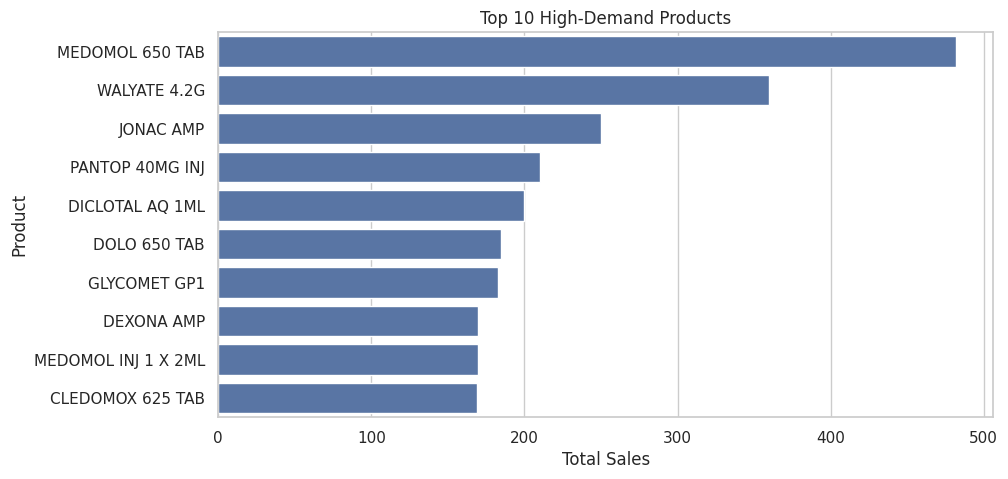

In [ ]:
top_sales = stock.sort_values(by="SaleTot", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sales["SaleTot"], y=top_sales["Name"])
plt.title("Top 10 High-Demand Products")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

2. Identifying Low-Demand / Dead Stock

Low-demand products: 1283 (56.67%)


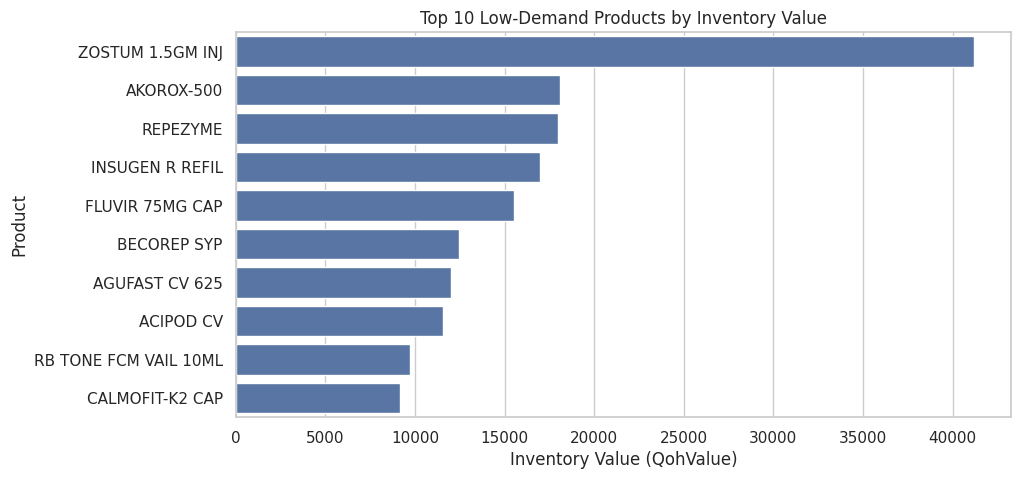

In [ ]:
# Identify low-demand products
low_sales = stock[stock["SaleTot"] <= 1]

# Total products
total_products = stock.shape[0]

# Count + percentage
low_count = low_sales.shape[0]
low_percent = (low_count / total_products) * 100

print(f"Low-demand products: {low_count} ({low_percent:.2f}%)")

# Top 10 low-demand products by highest inventory value
low_sales_sorted = low_sales.sort_values(by="QohValue", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    x=low_sales_sorted["QohValue"],
    y=low_sales_sorted["Name"]
)
plt.title("Top 10 Low-Demand Products by Inventory Value")
plt.xlabel("Inventory Value (QohValue)")
plt.ylabel("Product")
plt.show()


**Product Demand Insights:**

- Sales are highly concentrated in a few products.
- A large percentage of products have very low demand.
- Inventory strategy should focus on high-demand products.

3. Overstocked Products

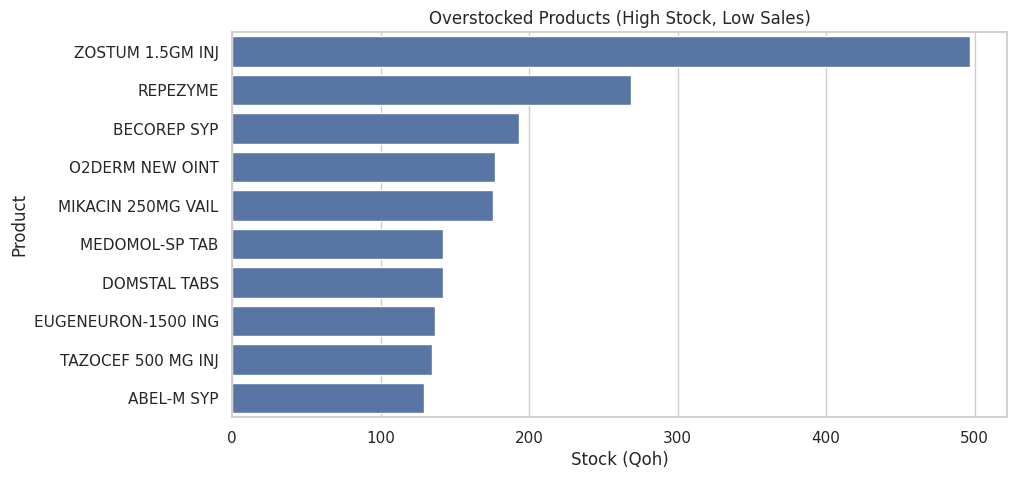

In [ ]:
# Identify Overstock Products

overstock = stock[
    (stock["Qoh"] > stock["Qoh"].mean()) &
    (stock["SaleTot"] < stock["SaleTot"].mean())
]

overstock = overstock.sort_values(by="Qoh", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=overstock["Qoh"], y=overstock["Name"])
plt.title("Overstocked Products (High Stock, Low Sales)")
plt.xlabel("Stock (Qoh)")
plt.ylabel("Product")
plt.show()

**Inventory Efficiency Insights:**

- Several products have high stock but low sales.
- Significant inventory value is locked in low-demand items.
- Indicates overstocking and inefficient inventory allocation.

4. Fast-Moving Products

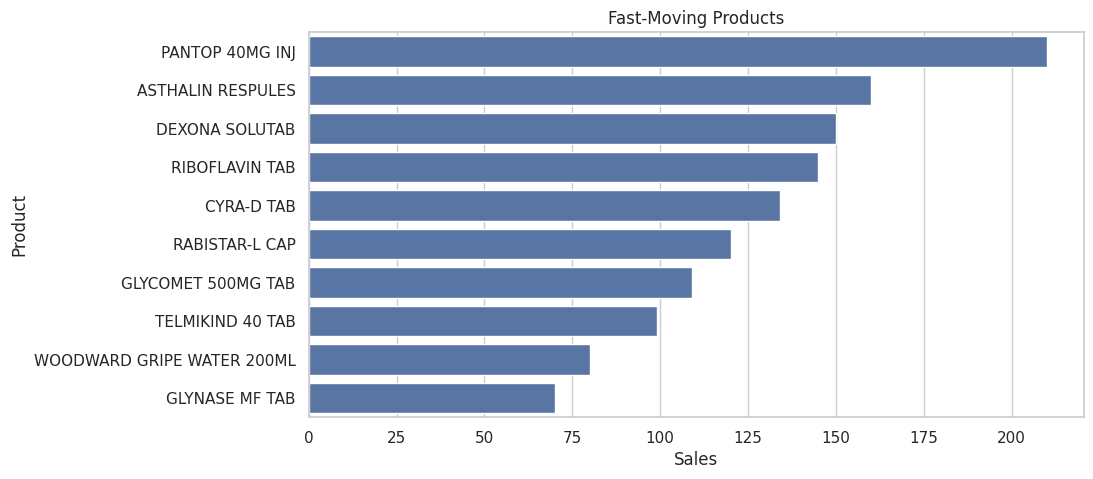

In [ ]:
# Identify Fast-moving products

fast_moving = stock[
    (stock["SaleTot"] > stock["SaleTot"].median()) &
    (stock["Qoh"] < stock["Qoh"].median())
]

fast_moving = fast_moving.sort_values(by="SaleTot", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=fast_moving["SaleTot"], y=fast_moving["Name"])
plt.title("Fast-Moving Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

5. Sales vs Stock Relationship

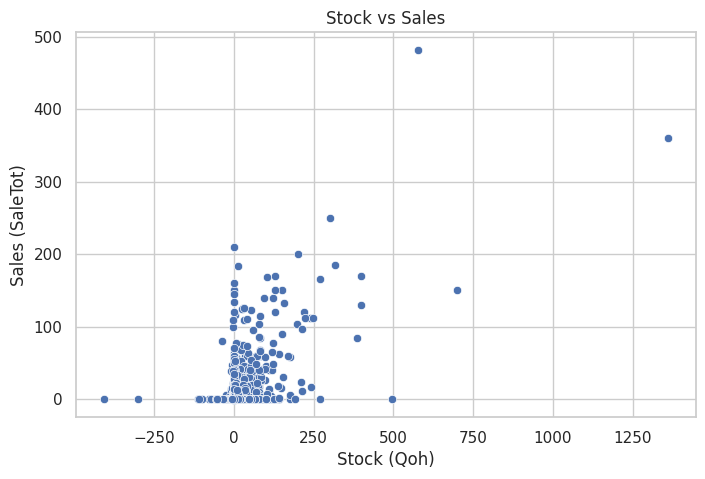

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=stock["Qoh"], y=stock["SaleTot"])
plt.title("Stock vs Sales")
plt.xlabel("Stock (Qoh)")
plt.ylabel("Sales (SaleTot)")
plt.show()

**Stock Movement Insights:**

- Fast-moving products are at risk of stock shortages.
- Weak alignment between stock and sales indicates poor demand planning.

# COMPANY LEVEL INSIGHTS

6. Company Contribution to Sales

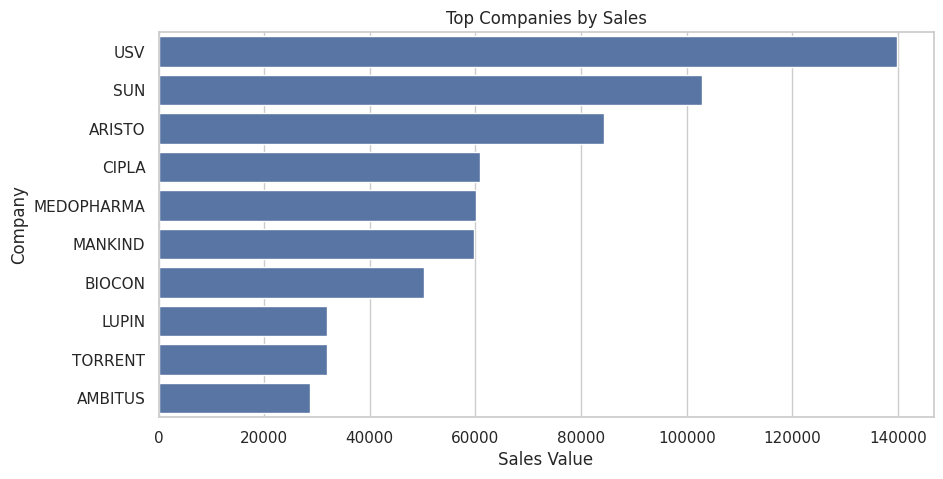

In [ ]:
top_companies = company_grouped.sort_values(by="Sale Value", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_companies["Sale Value"], y=top_companies["Company"])
plt.title("Top Companies by Sales")
plt.xlabel("Sales Value")
plt.ylabel("Company")
plt.show()

7. Purchase vs Sales Comparison

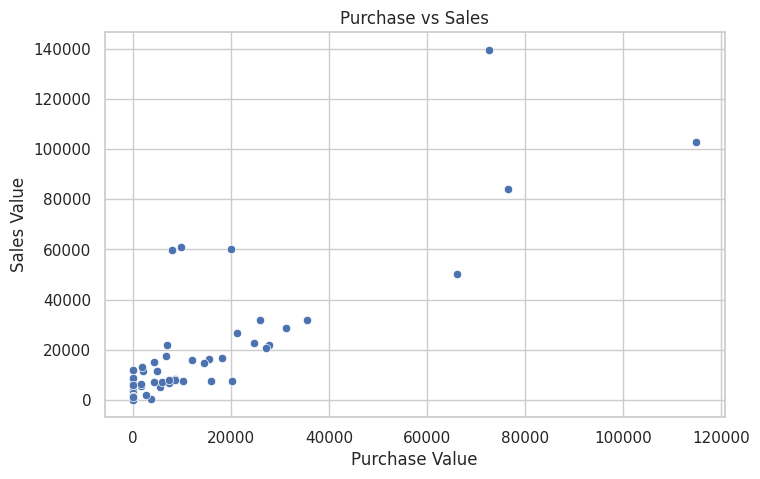

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=company_grouped["Purchase Value"], y=company_grouped["Sale Value"])
plt.title("Purchase vs Sales")
plt.xlabel("Purchase Value")
plt.ylabel("Sales Value")
plt.show()

8. High Profit Movement Indicator

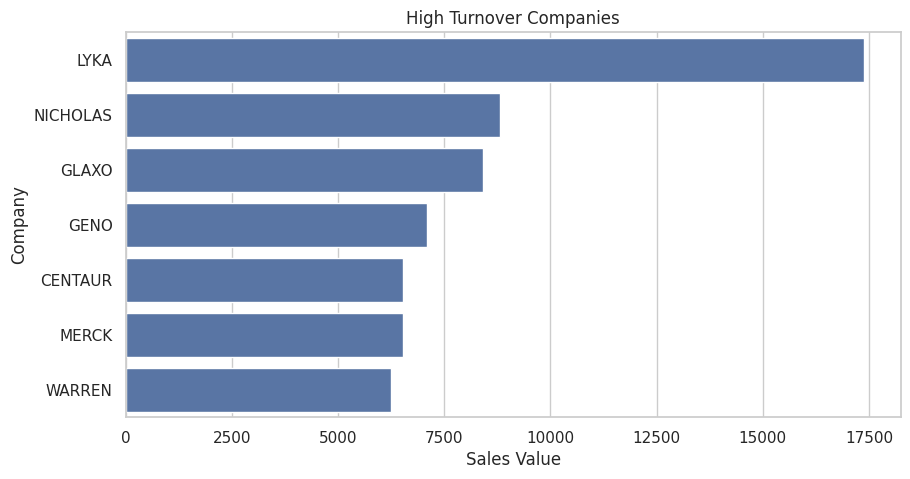

In [ ]:
fast_companies = company_grouped[
    (company_grouped["Sale Value"] > company_grouped["Sale Value"].median()) &
    (company_grouped["Closing Value"] < company_grouped["Closing Value"].median())
]

fast_companies = fast_companies.sort_values(by="Sale Value", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=fast_companies["Sale Value"], y=fast_companies["Company"])
plt.title("High Turnover Companies")
plt.xlabel("Sales Value")
plt.ylabel("Company")
plt.show()

9. Inventory Hoarding Companies

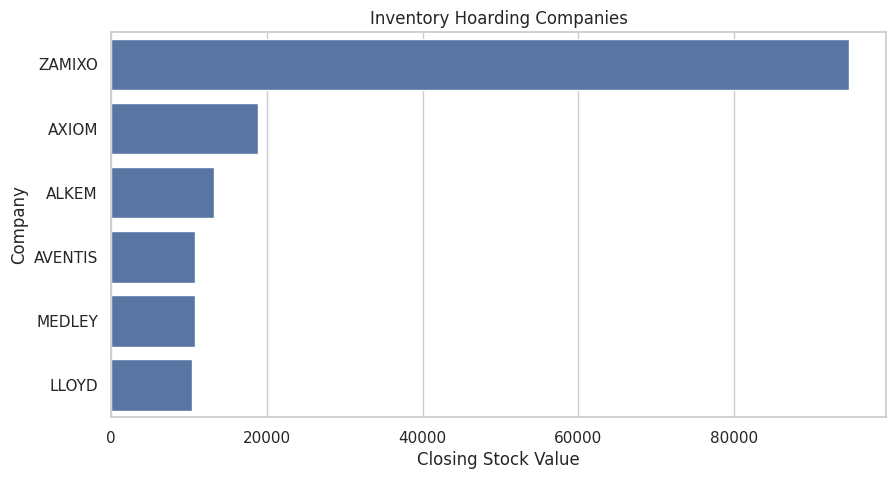

In [ ]:
hoarding = company_grouped[
    (company_grouped["Closing Value"] > company_grouped["Closing Value"].median()) &
    (company_grouped["Sale Value"] < company_grouped["Sale Value"].median())
]

hoarding = hoarding.sort_values(by="Closing Value", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=hoarding["Closing Value"], y=hoarding["Company"])
plt.title("Inventory Hoarding Companies")
plt.xlabel("Closing Stock Value")
plt.ylabel("Company")
plt.show()

**Company-Level Insights:**

- A few companies contribute significantly to overall sales, indicating dependency on key suppliers.
- Some companies show high purchase values but comparatively lower sales, suggesting inefficiencies in procurement.
- Stock movement analysis reveals uneven inventory turnover across companies.
- Certain companies maintain high inventory levels, indicating possible overstocking or slow-moving goods.

## Step 4: FEATURE ENGINEERING

**Data Leakage Prevention**

Certain columns such as `TotQty` and `Qoh` were removed from the dataset before modeling because they are directly derived from the target variable (`SaleTot`).

Including these features would result in data leakage and artificially inflated model performance.

In [ ]:
ml_df = stock.copy()

# Drop leakage columns
ml_df = ml_df.drop(columns=["TotQty", "Qoh"], errors="ignore")

print("ML base dataset shape:", ml_df.shape)
print(ml_df.columns)
print(ml_df.head())

ML base dataset shape: (2264, 8)
Index(['Company', 'Name', 'Packing', 'type', 'OStk', 'PurTot', 'SaleTot',
       'QohValue'],
      dtype='object')
  Company               Name  Packing  type  OStk  PurTot  SaleTot  QohValue
0   ABOTT  APETITE SYP 200ML    200.0    ml    13       0        2    754.15
1   ABOTT  AZRO-100 ORAL SYP     30.0    ml    28       0        3   1370.70
2   ABOTT       AZRO-200 SYP     30.0    ml    21       0        2   1098.92
3   ABOTT      BREATH-DX SYP    100.0    ml     7       0        0    330.62
4   ABOTT     BRUFEN 400 TAB     15.0  sach    24       0        0    439.84


In [ ]:
# Step: Create ML-ready dataset after base preparation

ml_final = ml_df.copy()

# Drop high-cardinality identifier column
ml_final = ml_final.drop(columns=["Name"], errors="ignore")

# One-hot encode categorical columns
ml_final = pd.get_dummies(
    ml_final,
    columns=["Company", "type"],
    drop_first=True
)

# Remove company dummy columns to avoid too many sparse features / overfitting
ml_model = ml_final.loc[:, ~ml_final.columns.str.startswith("Company_")].copy()

# Convert boolean dummy columns to integers
bool_cols = ml_model.select_dtypes(include="bool").columns
ml_model[bool_cols] = ml_model[bool_cols].astype(int)

print("ML final shape:", ml_model.shape)
print("\nColumns:")
print(ml_model.columns.tolist())
print("\nPreview:")
print(ml_model.head())

ML final shape: (2264, 15)

Columns:
['Packing', 'OStk', 'PurTot', 'SaleTot', 'QohValue', 'type_dose', 'type_gram', 'type_kit', 'type_lot', 'type_ml', 'type_sach', 'type_tab', 'type_unit', 'type_vial', 'type_x']

Preview:
   Packing  OStk  PurTot  SaleTot  QohValue  type_dose  type_gram  type_kit  \
0    200.0    13       0        2    754.15          0          0         0   
1     30.0    28       0        3   1370.70          0          0         0   
2     30.0    21       0        2   1098.92          0          0         0   
3    100.0     7       0        0    330.62          0          0         0   
4     15.0    24       0        0    439.84          0          0         0   

   type_lot  type_ml  type_sach  type_tab  type_unit  type_vial  type_x  
0         0        1          0         0          0          0       0  
1         0        1          0         0          0          0       0  
2         0        1          0         0          0          0       0  
3      

## Step 5: Feature-Target Split and Train-Test Split

In [ ]:
# Define features (X) and target (y)
X = ml_model.drop(columns=["SaleTot"])
y = ml_model["SaleTot"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=5
)

print("\nTrain/Test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X shape: (2264, 14)
y shape: (2264,)

Feature columns:
['Packing', 'OStk', 'PurTot', 'QohValue', 'type_dose', 'type_gram', 'type_kit', 'type_lot', 'type_ml', 'type_sach', 'type_tab', 'type_unit', 'type_vial', 'type_x']

Train/Test shapes:
X_train: (1811, 14)
X_test : (453, 14)
y_train: (1811,)
y_test : (453,)


## Step 6: Linear Regression

In [ ]:
# Scale data (needed for Ridge & Lasso)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

# 1. Linear Regression uses unscaled features
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

results.append({
    "Model": "Linear Regression",
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    "R2 Score": r2_score(y_test, y_pred_lr)
})

# 2. Ridge (linear model with L2 regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results.append({
    "Model": "Ridge Regression",
    "MAE": mean_absolute_error(y_test, y_pred_ridge),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
    "R2 Score": r2_score(y_test, y_pred_ridge)
})

# Lasso (linear model with L1 regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

results.append({
    "Model": "Lasso Regression",
    "MAE": mean_absolute_error(y_test, y_pred_lasso),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
    "R2 Score": r2_score(y_test, y_pred_lasso)
})

# Print results
results_df = pd.DataFrame(results)

print(results_df)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  6.956803  15.847525  0.459411
1   Ridge Regression  6.963920  15.847195  0.459434
2   Lasso Regression  6.915673  15.666612  0.471684


**1. Actual vs Predicted**

**2. Residual Plot**

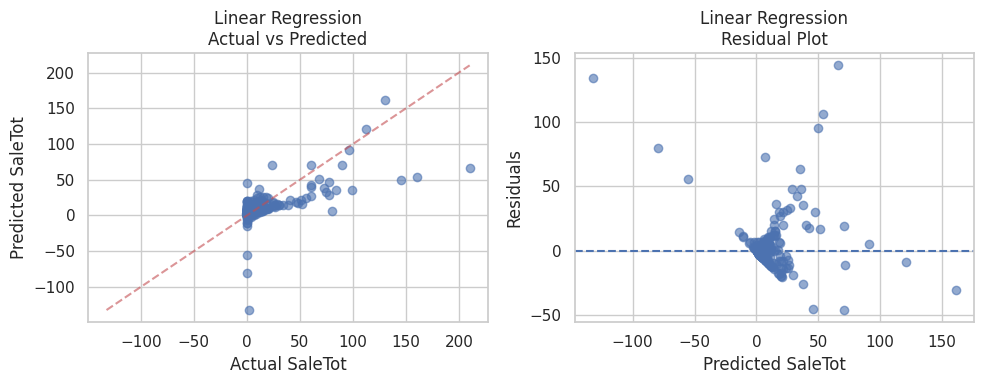

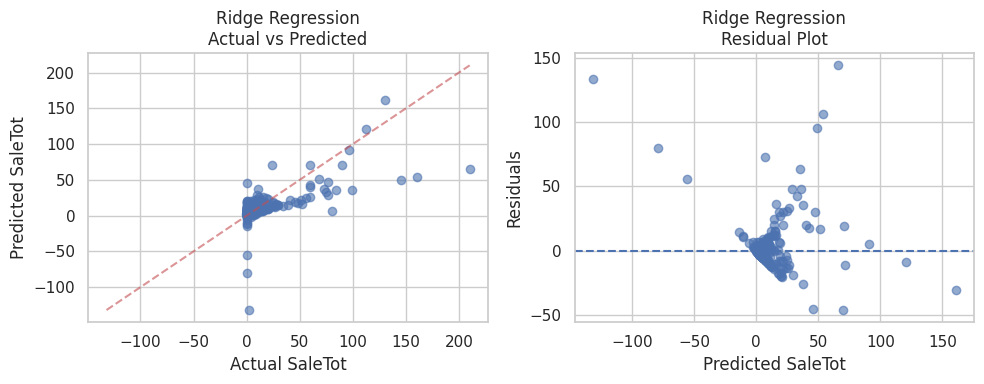

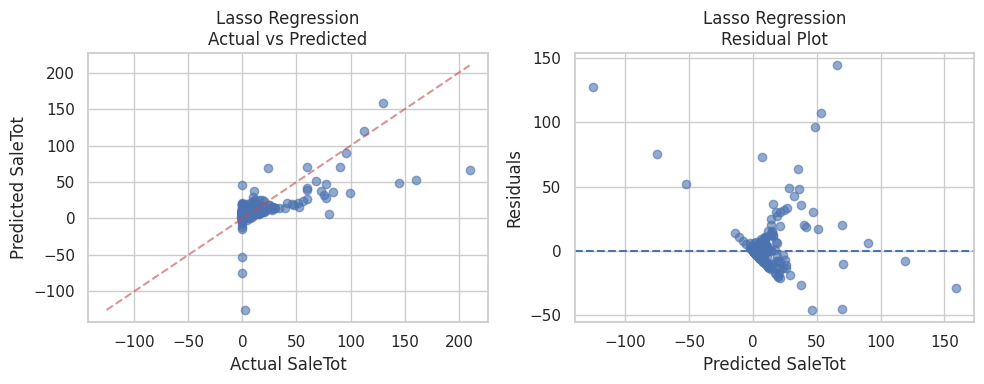

In [ ]:
def plot_subplots(y_test, y_pred, model_name):

    residuals = y_test - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 1. Actual vs Predicted
    axes[0].scatter(y_test, y_pred, alpha=0.6)

    # Ideal line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.6)

    axes[0].set_xlabel("Actual SaleTot")
    axes[0].set_ylabel("Predicted SaleTot")
    axes[0].set_title(f"{model_name}\nActual vs Predicted")

    # 2. Residual Plot
    axes[1].scatter(y_pred, residuals, alpha=0.6)
    axes[1].axhline(0, linestyle='--')
    axes[1].set_xlabel("Predicted SaleTot")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title(f"{model_name}\nResidual Plot")

    plt.tight_layout()
    plt.show()
plot_subplots(y_test, y_pred_lr, "Linear Regression")
plot_subplots(y_test, y_pred_ridge, "Ridge Regression")
plot_subplots(y_test, y_pred_lasso, "Lasso Regression")

## Step 7: Decision Tree

In [ ]:
# Train Decision Tree Regressor

dt = DecisionTreeRegressor(max_depth=5, random_state=5)
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

# Evaluation Metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regression Metrics")
print("MAE       :", mae_dt)
print("RMSE      :", rmse_dt)
print("R2 Score  :", r2_dt)

results.append({
    "Model": "Decision Tree",
    "MAE": mae_dt,
    "RMSE": rmse_dt,
    "R2 Score": r2_dt
})

Decision Tree Regression Metrics
MAE       : 6.192946827177259
RMSE      : 12.999784411077709
R2 Score  : 0.636238887539558


**1. Actual vs Predicted**

**2. Residual Plot**

**3. Feature Importance**

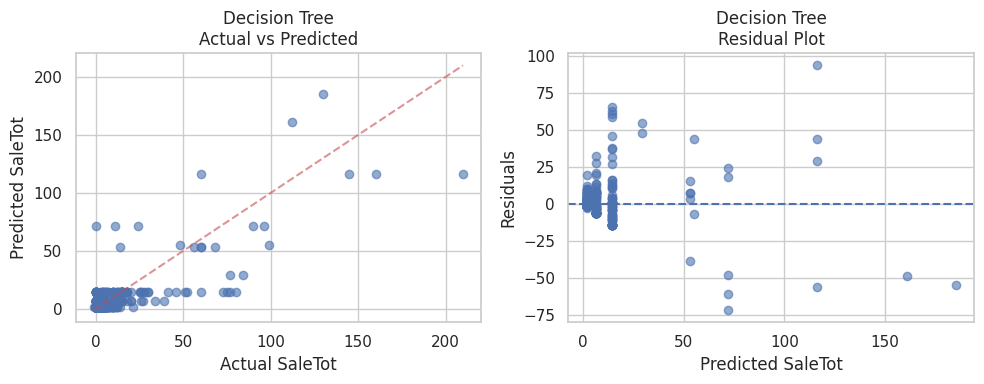

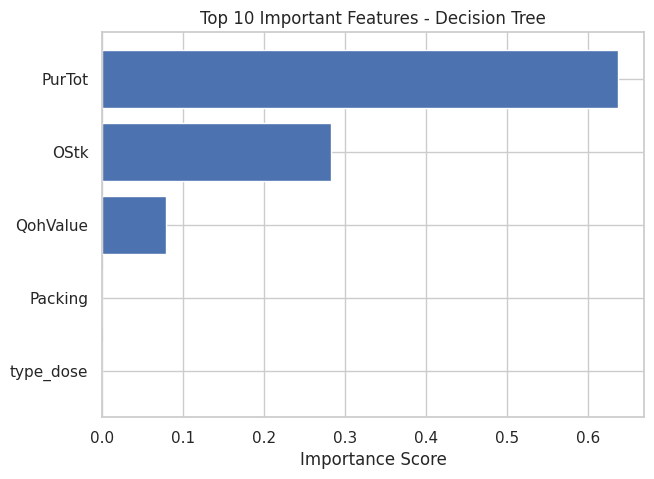

In [ ]:
# Plotting Actual Vs Predicted & Residual Plot

plot_subplots(y_test, y_pred_dt, "Decision Tree")

# Feature Importance
importance = dt.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(7, 5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.title("Top 10 Important Features - Decision Tree")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()

## Step 8: Random Forest

In [ ]:
# Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=5
)

rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

results.append({
    "Model": "Random Forest",
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "R2 Score": r2_rf
})

Random Forest Performance:
MAE : 4.5106225165562925
RMSE: 10.89944134340077
R2  : 0.7442872125413229


**1. Actual vs Predicted**

**2. Residual Plot**

**3. Feature Importance**

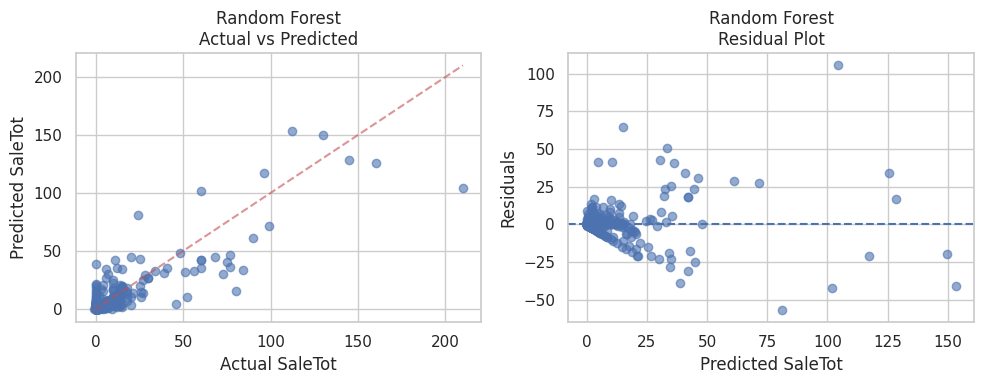

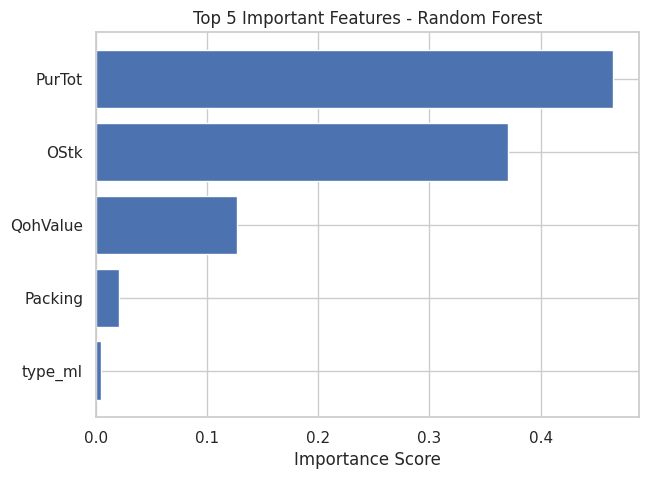

In [ ]:
# Plotting Actual Vs Predicted & Residual Plot

plot_subplots(y_test, y_pred_rf, "Random Forest")

# Feature Importance
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(7,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.title("Top 5 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()

## Step 9: Gradient Boosting

In [ ]:
# Train Gradient Boosting Regressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=10
)

gbr.fit(X_train, y_train)

# Predictions
y_pred_gbr = gbr.predict(X_test)

# Metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting Performance:")
print("MAE :", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2  :", r2_gbr)

results.append({
    "Model": "Gradient Boosting",
    "MAE": mae_gbr,
    "RMSE": rmse_gbr,
    "R2 Score": r2_gbr
})

Gradient Boosting Performance:
MAE : 4.3480397999853135
RMSE: 9.9549397465177
R2  : 0.7866850759507609


**1. Actual vs Predicted**

**2. Residual Plot**

**3. Feature Importance**

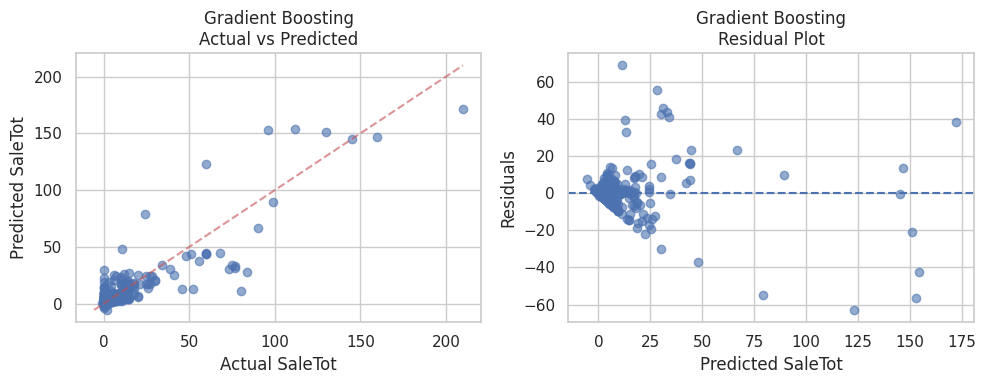

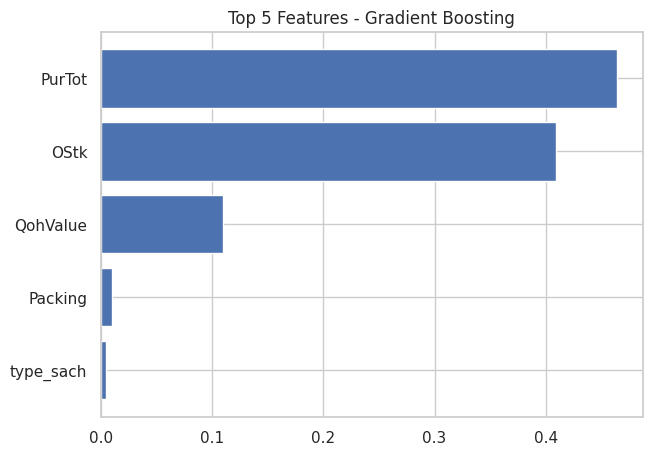

In [ ]:
# Plotting Actual Vs Predicted & Residual Plot

plot_subplots(y_test, y_pred_gbr, "Gradient Boosting")

#Feature Importance
importance = gbr.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(7,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.title("Top 5 Features - Gradient Boosting")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()

## Step  10: XG Boost

In [ ]:
from xgboost import XGBRegressor

# Train XGBoost Regressor
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=5
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Performance:")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

results.append({
    "Model": "XG Boost",
    "MAE": mae_xgb,
    "RMSE": rmse_xgb,
    "R2 Score": r2_xgb
})

XGBoost Performance:
MAE : 4.722136497497559
RMSE: 11.258812398668786
R2  : 0.7271467447280884


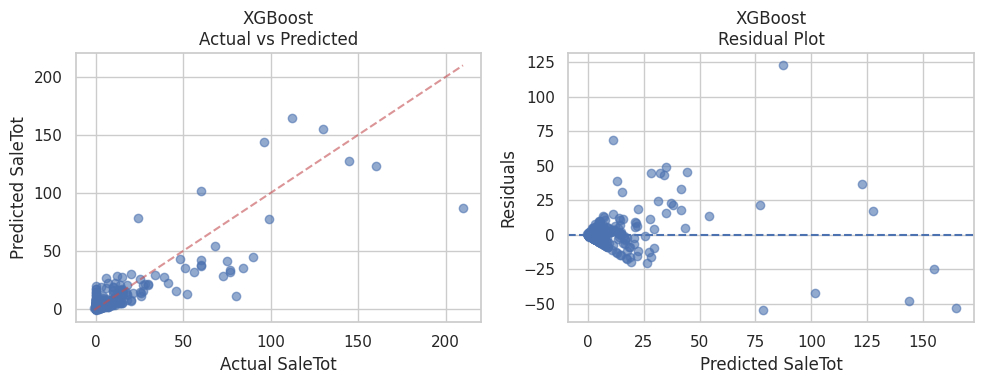

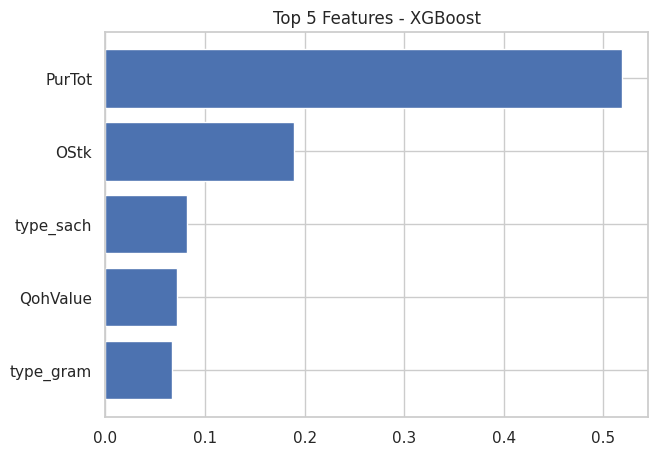

In [ ]:
# Plotting Actual Vs Predicted & Residual Plot

plot_subplots(y_test, y_pred_xgb, "XGBoost")

#Feature Importance
importance = xgb.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(7,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.title("Top 5 Features - XGBoost")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()

## Step 11: Model Comparison

In [ ]:
# All Models comparison
results_df = pd.DataFrame(results)

print(results_df)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  6.956803  15.847525  0.459411
1   Ridge Regression  6.963920  15.847195  0.459434
2   Lasso Regression  6.915673  15.666612  0.471684
3      Decision Tree  6.192947  12.999784  0.636239
4      Random Forest  4.510623  10.899441  0.744287
5  Gradient Boosting  4.348040   9.954940  0.786685
6           XG Boost  4.722136  11.258812  0.727147


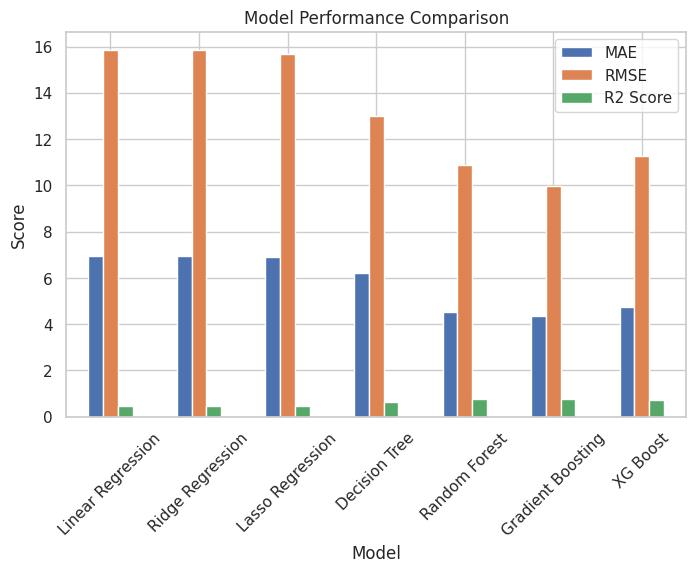

In [ ]:
results_df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Step 12 Hyper Parameter Tuning

We perform Hyper parameter tuning using RandomizedSearchCV on:
1. Random Forest
2. Gradient Boosting
3. XGBoost


In [ ]:
# Parameter Tuning for Random Forest Regressor

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=5),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)
print("Best Random Forest CV R2 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest CV R2 Score:
0.7419605620448364


In [ ]:
# Parameter Tuning for Gradient Boosting

param_grid_gb = {
    'n_estimators': [100, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gb,
    cv=3,
    scoring="r2",
    n_jobs=-1,
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("Best Gradient Boosting CV R2 Score:")
print(gb_grid.best_score_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
Best Gradient Boosting CV R2 Score:
0.8020815259073372


In [ ]:
# Parameter Tuning for XG Boost

param_grid_xg = {
    'n_estimators': [100, 300],
    'max_depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
    'reg_alpha': [0.5, 1],
    'reg_lambda': [1, 1.5]
}

xg_grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

xg_grid.fit(X_train, y_train)

print("Best XG Boost Parameters:")
print(xg_grid.best_params_)
print("Best XG Boost CV R2 Score:")
print(xg_grid.best_score_)

Best XG Boost Parameters:
{'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 0.8}
Best XG Boost CV R2 Score:
0.8052375793457032


## Step 13: Final Model Evaluation

In [ ]:
# Metrics function
results = []

def evaluate(model, name):

    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, rmse, mae, r2])

    print(f"{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

# Get best models
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_
best_xg = xg_grid.best_estimator_

# Evaluate
evaluate(best_rf,"Random Forest")
evaluate(best_gb,"Gradient Boosting")
evaluate(best_xg,"XGBoost")

Random Forest
RMSE: 10.74971957965632
MAE : 4.558990440051301
R2  : 0.7512642326154886
Gradient Boosting
RMSE: 9.692284269119686
MAE : 4.414634658814398
R2  : 0.7977929674328053
XGBoost
RMSE: 10.373410390389527
MAE : 4.595387935638428
R2  : 0.7683740854263306


## Step 14: ENSEMBLE Models

# Voting

In [ ]:
from sklearn.ensemble import VotingRegressor

# Weighted Voting
weights_list = [
    [1,1,1], # Equal Weights
    [1,3,2],
    [1,4,2],
    [1,5,3],
    [2,5,3]
]

weights_results = []
for weights in weights_list:

    model = VotingRegressor(
        estimators=[
            ('rf', best_rf),
            ('gb', best_gb),
            ('xgb', best_xg)
        ],
        weights=weights
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    weights_results.append([
        str(weights),
        rmse,
        mae,
        r2
    ])

    results.append([
        f"Voting {weights}",
        rmse,
        mae,
        r2
    ])

weights_df = pd.DataFrame(
    weights_results,
    columns=["Weights", "RMSE", "MAE", "R2"]
)

weights_df.sort_values(
    by="R2",
    ascending=False
)

,Weights,RMSE,MAE,R2
2,"[1, 4, 2]",9.876454,4.422043,0.790035
3,"[1, 5, 3]",9.888741,4.434641,0.789513
4,"[2, 5, 3]",9.920461,4.419982,0.788160
1,"[1, 3, 2]",9.920503,4.429442,0.788158
0,"[1, 1, 1]",10.050152,4.430305,0.782585


# Stacking

In [ ]:
from sklearn.ensemble import StackingRegressor

# Linear Meta Model
stack_lr = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xg)
    ],
    final_estimator=LinearRegression()
)
stack_lr.fit(X_train, y_train)
evaluate(stack_lr, "Stacking LR")

# Ridge Meta Model
stack_ridge = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xg)
    ],
    final_estimator=Ridge()
)
stack_ridge.fit(X_train, y_train)
evaluate(stack_ridge, "Stacking Ridge")

# Lasso Meta Model
stack_lasso = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xg)
    ],
    final_estimator=Lasso()
)
stack_lasso.fit(X_train, y_train)
evaluate(stack_lasso, "Stacking Lasso")

# Random Forest Meta Model
stack_rf = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xg)
    ],
    final_estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
)
stack_rf.fit(X_train, y_train)
evaluate(stack_rf, "Stacking RF")

# Gradient Boosting Meta Model
stack_gbr = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xg)
    ],
    final_estimator=GradientBoostingRegressor(
        random_state=42
    )
)
stack_gbr.fit(X_train, y_train)
evaluate(stack_gbr, "Stacking GBR")

# XGBoost Meta Model
stack_xgb = StackingRegressor(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
        ('xgb', best_xg)
    ],
    final_estimator=XGBRegressor(
        random_state=42
    )
)
stack_xgb.fit(X_train, y_train)
evaluate(stack_xgb, "Stacking XGB")

Stacking LR
RMSE: 10.10054364785102
MAE : 4.562015633954113
R2  : 0.7803994271026833
Stacking Ridge
RMSE: 10.100529223664184
MAE : 4.562006620401107
R2  : 0.7804000543080183
Stacking Lasso
RMSE: 10.087382256343922
MAE : 4.53011170737804
R2  : 0.7809713499939
Stacking RF
RMSE: 10.759673981852957
MAE : 4.699166351308736
R2  : 0.7508033531916362
Stacking GBR
RMSE: 11.438390103832159
MAE : 4.716651608536892
R2  : 0.7183733317658786
Stacking XGB
RMSE: 12.845583002944899
MAE : 5.100602626800537
R2  : 0.6448174715042114


## All Models Comparison

In [ ]:
# Compare all Voting and Meta Models

results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "MAE", "R2"]
)
results_df = results_df.sort_values(
    by="R2",
    ascending=False
)
results_df

,Model,RMSE,MAE,R2
1,Gradient Boosting,9.692284,4.414635,0.797793
5,"Voting [1, 4, 2]",9.876454,4.422043,0.790035
6,"Voting [1, 5, 3]",9.888741,4.434641,0.789513
7,"Voting [2, 5, 3]",9.920461,4.419982,0.788160
4,"Voting [1, 3, 2]",9.920503,4.429442,0.788158
3,"Voting [1, 1, 1]",10.050152,4.430305,0.782585
10,Stacking Lasso,10.087382,4.530112,0.780971
9,Stacking Ridge,10.100529,4.562007,0.780400
8,Stacking LR,10.100544,4.562016,0.780399
2,XGBoost,10.373410,4.595388,0.768374


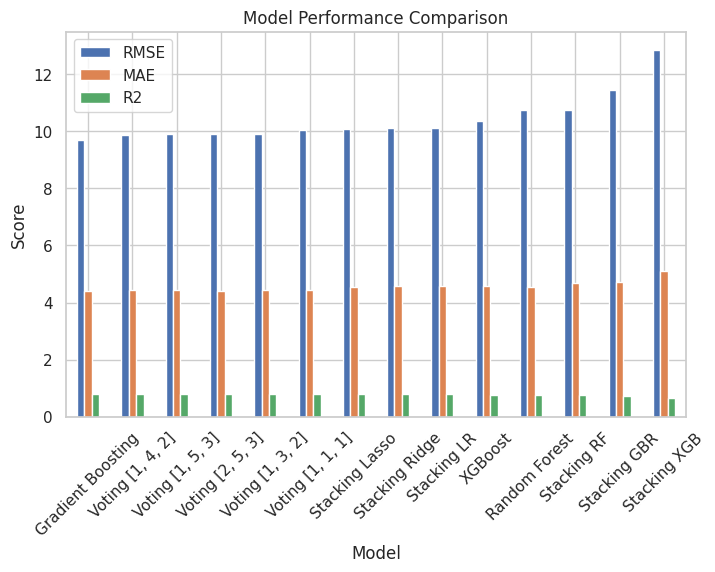

In [ ]:
results_df.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Step 15: Final Model: Gradient Boosting Regressor

### The Gradient Boosting model was selected as the final model for this project.

In [ ]:
# Best Model

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:")
print(best_model_name)

Best Model:
Gradient Boosting


In [ ]:
# Saving results

results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

weights_df.to_csv(
    "weighted_voting_results.csv",
    index=False
)

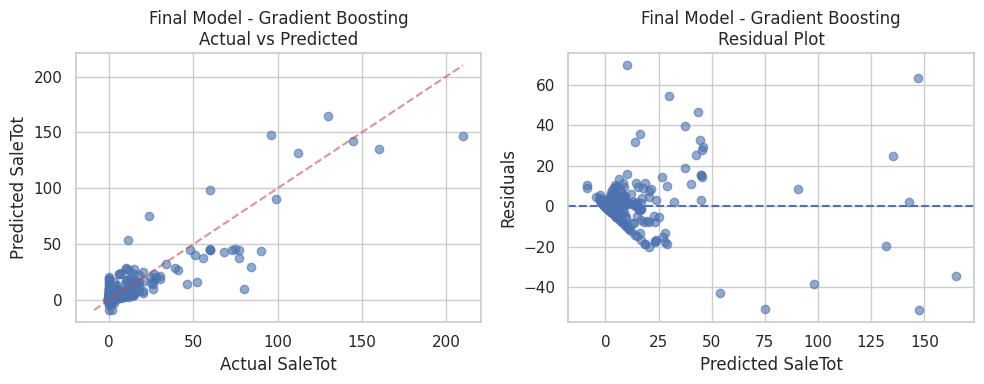

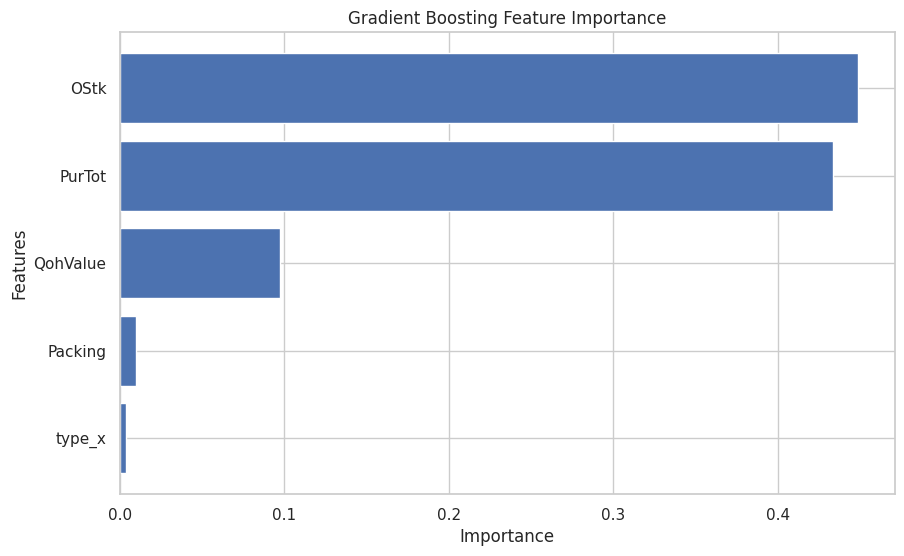

In [ ]:
# Plotting Actual Vs Predicted & Residual Plot
y_pred_gb_tuned = best_gb.predict(X_test)
plot_subplots(y_test, y_pred_gb_tuned, "Final Model - Gradient Boosting")

#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head()

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Gradient Boosting Feature Importance")

plt.gca().invert_yaxis()


plt.show()

### Model Comparison Insight

- Linear models performed poorly, indicating non-linear relationships in the data
- Decision Tree improved performance but showed instability
- Random Forest significantly improved results due to ensemble learning
- XGBoost performed well initially but did not generalize as effectively after tuning

Gradient Boosting performed best among all the ensemble models due to it's working with Non-linear Data


## Step 15: Error Analysis

In [ ]:
# Analysing top errors when the model fails

error_df = X_test.copy()

error_df["Actual"] = y_test
error_df["Predicted"] = y_pred_gb_tuned

error_df["Error"] = error_df["Actual"] - error_df["Predicted"]
error_df["Absolute_Error"] = np.abs(error_df["Error"])

error_df = error_df.sort_values(
    "Absolute_Error",
    ascending=False
)

top20_errors = error_df.head(20)

top20_errors.to_csv(
    "top20_errors.csv",
    index=False
)

print(top20_errors[
    [
        "Actual",
        "Predicted",
        "Absolute_Error"
    ]
].head())


      Actual   Predicted  Absolute_Error
911       80   10.373986       69.626014
260      210  146.819313       63.180687
1373      84   29.698739       54.301261
1390      96  147.427253       51.427253
1600      24   75.035417       51.035417


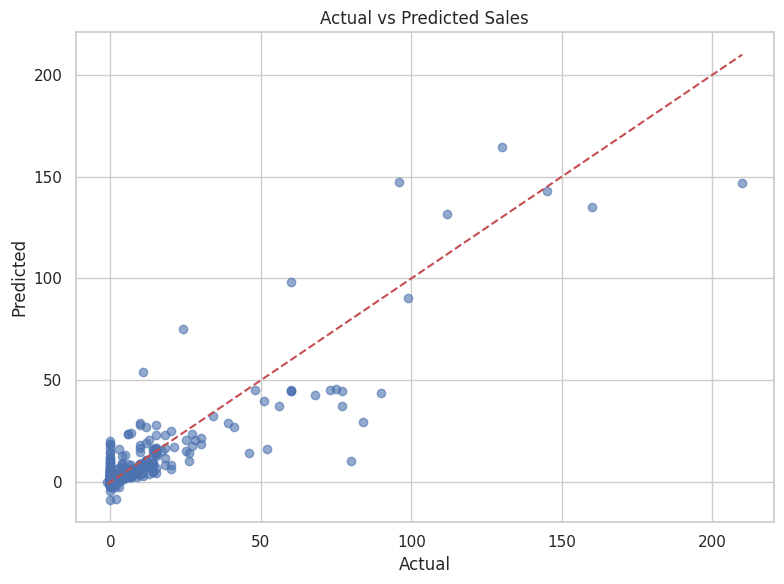

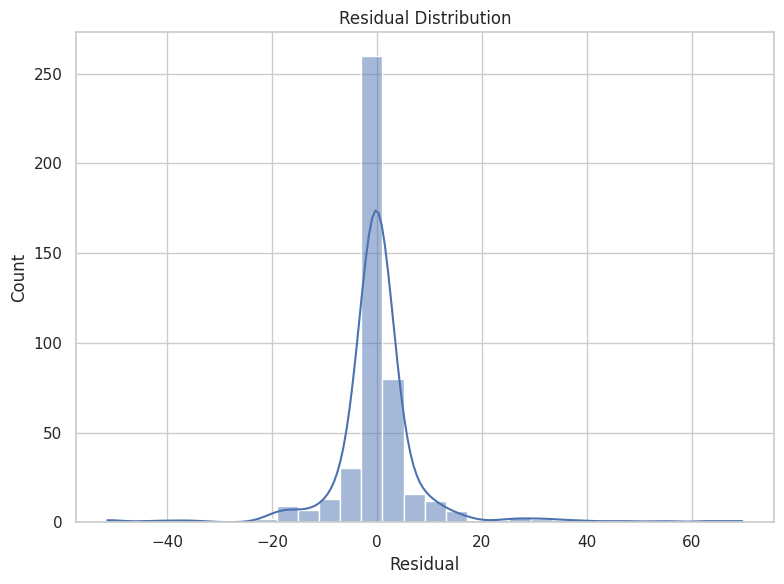

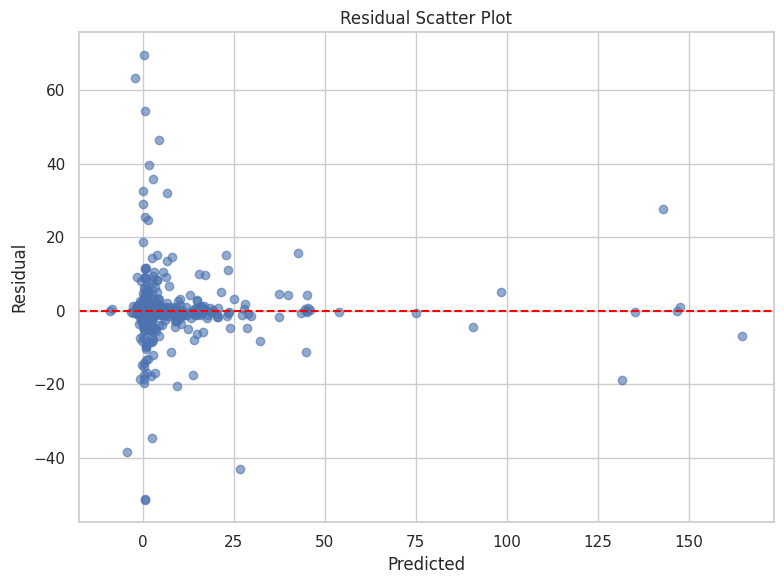

In [ ]:
# Actual vs Predicted

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gb_tuned, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()


# Residual Histogram

plt.figure(figsize=(8,6))

sns.histplot(
    error_df["Error"],
    bins=30,
    kde=True
)

plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.tight_layout()
plt.savefig("residual_histogram.png")
plt.show()


# Residual Scatter

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_gb_tuned,
    error_df["Error"],
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Scatter Plot")

plt.tight_layout()
plt.savefig("residual_scatter.png")
plt.show()

In [ ]:
q1 = np.percentile(y_test,25)
q3 = np.percentile(y_test,75)

low_mask = y_test <= q1
mid_mask = (y_test > q1) & (y_test < q3)
high_mask = y_test >= q3

results = pd.DataFrame({
    "Demand_Group":[
        "Low",
        "Medium",
        "High"
    ],
    "Count":[
        low_mask.sum(),
        mid_mask.sum(),
        high_mask.sum()
    ],
    "MAE":[
        mean_absolute_error(y_test[low_mask],y_pred_gb_tuned[low_mask]),
        mean_absolute_error(y_test[mid_mask],y_pred_gb_tuned[mid_mask]),
        mean_absolute_error(y_test[high_mask],y_pred_gb_tuned[high_mask])
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test[low_mask],y_pred_gb_tuned[low_mask])),
        np.sqrt(mean_squared_error(y_test[mid_mask],y_pred_gb_tuned[mid_mask])),
        np.sqrt(mean_squared_error(y_test[high_mask],y_pred_gb_tuned[high_mask]))
    ]
})

print(results)

results.to_csv(
    "demand_group_performance.csv",
    index=False
)

  Demand_Group  Count        MAE       RMSE
0          Low    232   2.182696   3.979872
1       Medium    101   1.646200   2.714235
2         High    120  11.059816  17.826988


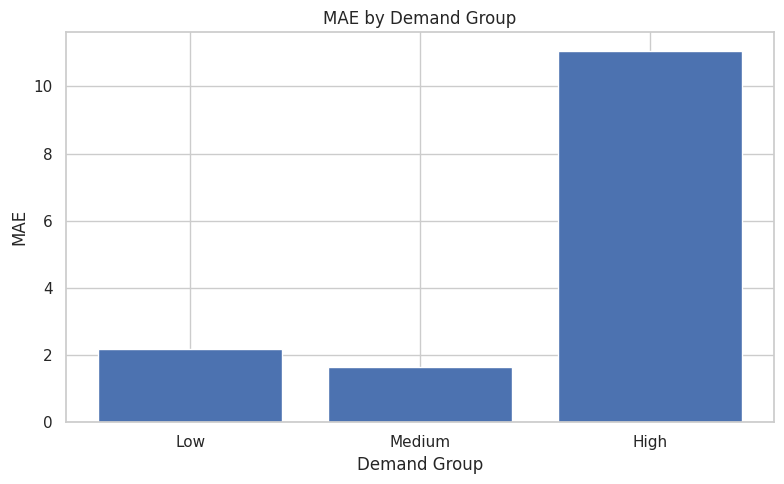

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Demand_Group"],
    results["MAE"]
)

plt.title("MAE by Demand Group")
plt.xlabel("Demand Group")
plt.ylabel("MAE")

plt.tight_layout()
plt.savefig("demand_group_mae.png")
plt.show()

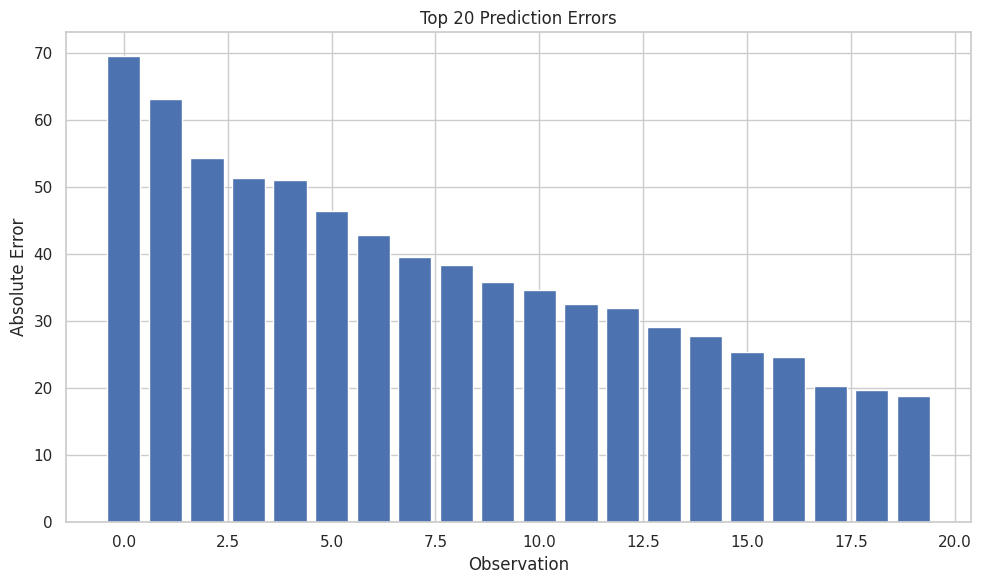

In [ ]:
top20 = error_df.nlargest(
    20,
    "Absolute_Error"
).copy()

plt.figure(figsize=(10,6))

plt.bar(
    range(len(top20)),
    top20["Absolute_Error"]
)

plt.title("Top 20 Prediction Errors")
plt.xlabel("Observation")
plt.ylabel("Absolute Error")

plt.tight_layout()
plt.savefig("top20_errors_plot.png")
plt.show()

## Step 16: SHAP

SHAP explains why a machine learning model made a particular prediction

In [ ]:
# Create Explainer and Compute shap values

import shap
explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test)

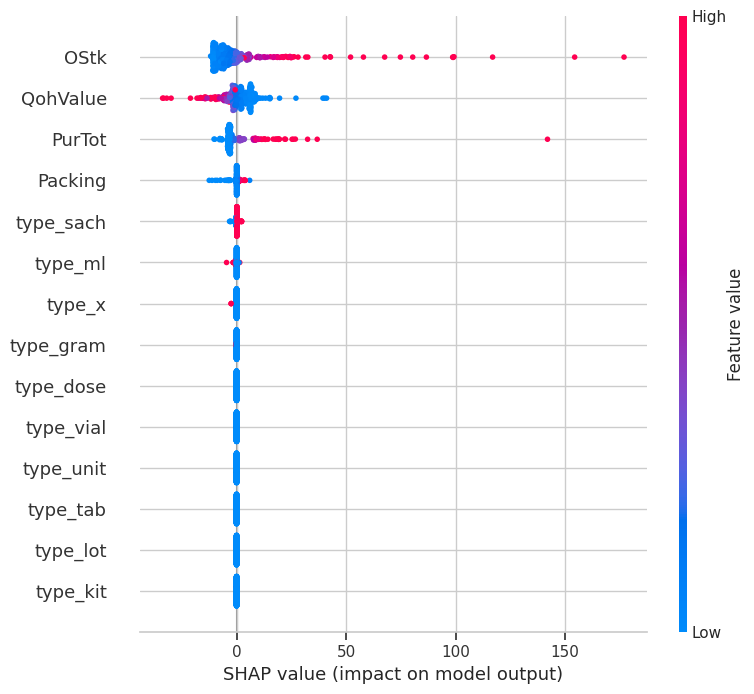

In [ ]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test
)

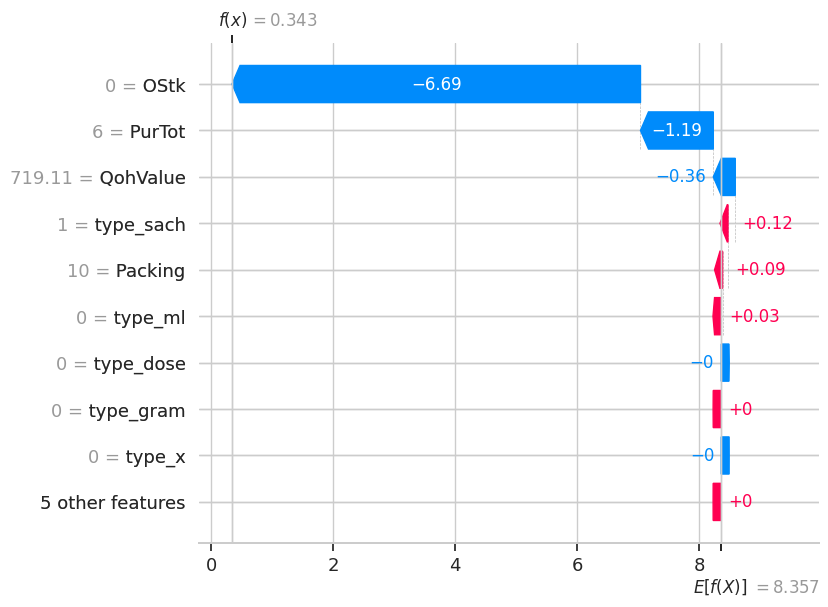

In [ ]:
# SHAP WaterFall Plot

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

## Step 17: K-Means Clustering

we apply **KMeans Clustering** to group products based on their stock and sales behavior.

In [ ]:
# Select features for clustering

cluster_df = ml_model[["OStk", "PurTot", "SaleTot", "QohValue"]].copy()

# Scale data for Clustering
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_df)

print(cluster_df.head())

   OStk  PurTot  SaleTot  QohValue
0    13       0        2    754.15
1    28       0        3   1370.70
2    21       0        2   1098.92
3     7       0        0    330.62
4    24       0        0    439.84


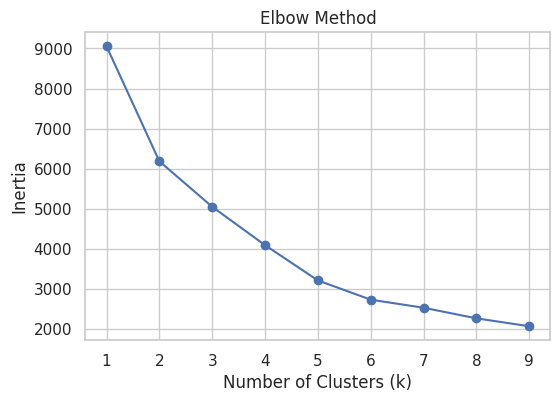

In [ ]:
from sklearn.cluster import KMeans

# Training KMeans Cluster Model in range from 1-10
inertia = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

From the curve, it shows a noticeable bend around **k = 4**

Hence we are selecting n_cluster = 4

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=5)
clusters = kmeans.fit_predict(cluster_scaled)

cluster_df["Cluster"] = clusters

print(cluster_df.head())

   OStk  PurTot  SaleTot  QohValue  Cluster
0    13       0        2    754.15        0
1    28       0        3   1370.70        0
2    21       0        2   1098.92        0
3     7       0        0    330.62        0
4    24       0        0    439.84        0


In [ ]:
cluster_labels = {
    0: "Low Demand",
    1: "Fast Moving",
    2: "High Value",
    3: "Bulk/Moderate Demand"
}

cluster_df["Cluster_Label"] = cluster_df["Cluster"].map(cluster_labels)

print(cluster_df.head())

   OStk  PurTot  SaleTot  QohValue  Cluster Cluster_Label
0    13       0        2    754.15        0    Low Demand
1    28       0        3   1370.70        0    Low Demand
2    21       0        2   1098.92        0    Low Demand
3     7       0        0    330.62        0    Low Demand
4    24       0        0    439.84        0    Low Demand


In [ ]:
# Cluster Count

cluster_df["Cluster_Label"].value_counts()

,count
Cluster_Label,
Low Demand,2043
High Value,173
Fast Moving,45
Bulk/Moderate Demand,3


Cluster Validation using Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, cluster_df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.7027804865756901


## Cluster Profiling

## K-Means Clustering Analysis

Based on the average values of stock, sales, and inventory value, the products were grouped into four distinct clusters:

**Cluster 0 – Low-Demand Products**

* Low sales volume and low stock movement.
* Products with slow inventory turnover.

**Cluster 1 – Fast-Moving Products**

* High sales volume and frequent stock movement.
* Products with strong customer demand.

**Cluster 2 – High-Value Products**

* High inventory value and significant financial investment.
* Products requiring careful inventory monitoring.

**Cluster 3 – Bulk and Moderate-Demand Products**

* Moderate demand with larger inventory quantities.
* Products supporting regular operations with occasional high-volume transactions.

### Conclusion

The clustering analysis identified distinct product segments based on inventory characteristics. These insights can support inventory optimization, demand forecasting, stock management, and business decision-making.


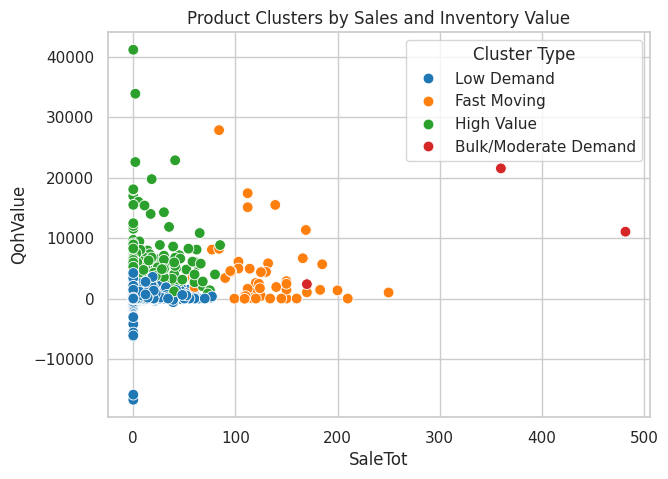

In [ ]:
# Cluster Plotting

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=cluster_df,
    x="SaleTot",
    y="QohValue",
    hue="Cluster_Label",
    palette="tab10",
    s=60
)

plt.title("Product Clusters by Sales and Inventory Value")
plt.xlabel("SaleTot")
plt.ylabel("QohValue")
plt.legend(title="Cluster Type")
plt.grid(True)

plt.show()

## Final Conclusion and Report

**Final Model Selection**

After comparing multiple models, the **XGBoost** was selected as the final model.

**Reason for Selection:**
- Achieved the best performance on test data
- Lower RMSE and MAE compared to other models
- Higher R² score after tuning
- More stable and less prone to overfitting

Although Gradient Boosting and Random Forest showed strong initial performance, it did not generalize well after tuning.

**Key Insights from Supervised Learning**

- Tree-based models performed significantly better than linear models
- The relationship between features and `SaleTot` is non-linear
- XGBoost captured these patterns effectively
- Feature importance analysis revealed that stock-related variables have a strong influence on sales

**Key Insights from Clustering**

KMeans clustering grouped products into meaningful categories:

- Low Demand Products
- Fast Moving Products
- High Value Inventory
- Bulk Transactions
- Moderate Demand Products

These clusters help in understanding product behavior and improving inventory decisions.

## Business Conclusion

Based on the analysis:

- Products with higher stock and consistent purchases tend to have higher sales
- A large number of products fall into low-demand categories, indicating possible overstocking
- High-value products require careful monitoring to avoid inventory risk
- Fast-moving products should be prioritized for restocking

The model can help predict product demand and support better inventory management decisions.

## Final Conclusion

This project demonstrates that ensemble tree-based models are highly effective for inventory prediction tasks. Additionally, clustering provides valuable insights into product behavior, helping in better stock management and decision-making.

### Achievements:
- Built multiple regression models and compared their performance
- Selected the best-performing model (XGBoost)
- Applied hyperparameter tuning for optimization
- Performed clustering to identify product behavior patterns

### Outcome:
The combination of supervised and unsupervised learning provided both predictive insights and business understanding of the data.

## Step 18: Saving Model (Gradient Boost)

In [ ]:
import joblib

joblib.dump(best_gb,
            "medical_inventory_gb_model.pkl")

joblib.dump(
    X_train.columns.tolist(),
    "model_columns.pkl"
)

['model_columns.pkl']

In [ ]:
import pandas as pd
import joblib

product_df = pd.read_csv(
    "Product_Level_Data_Final.csv"
)

product_df.to_pickle(
    "dashboard_data.pkl"
)

print("Data saved successfully!")

Data saved successfully!
